## Linear Regression

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics

### Clean Data

In [5]:
weather = pd.read_csv("weatherdataCMSE.csv")

weather.head()

,STATION,NAME,DATE,AWND,PGTM,PRCP,TAVG,TMAX,TMIN,WDF2,WDF5,WSF2,WSF5,WT01,WT02,WT03,WT08
0,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-01,16.33,941.0,0.00,NaN,33.0,19.0,240.0,230.0,23.9,31.1,NaN,NaN,NaN,NaN
1,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-02,6.71,1323.0,0.00,NaN,36.0,27.0,260.0,250.0,16.1,23.0,NaN,NaN,NaN,NaN
2,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-03,6.71,1221.0,0.38,NaN,37.0,26.0,110.0,110.0,16.1,21.0,NaN,NaN,NaN,NaN
3,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-04,9.84,2304.0,0.07,NaN,38.0,21.0,300.0,290.0,23.9,33.1,NaN,NaN,NaN,NaN
4,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-05,13.20,445.0,0.00,NaN,21.0,8.0,310.0,320.0,23.0,36.9,NaN,NaN,NaN,NaN


Make all N/A values 0 to use for regression models.

In [75]:
weather = weather.fillna(0)
#len(weather[weather["WT03"] == 0])
len(weather[weather["WT03"] == 1])

38

In [76]:
thunder = weather[weather["WT03"]==1]
no_thunder = weather[weather["WT03"]==0]
no_thunder = no_thunder.sample(n=38, random_state=2)
sample_t = pd.concat([thunder, no_thunder])

Create training and testing sets with the smaller data set of thunder, using precipitation, average wind speed, and peak wind gust time.

In [77]:
labels = sample_t["WT03"]
features = sample_t.iloc[:,3:6]
features
train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features,labels, test_size=.25)

In [78]:
logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.511275
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   WT03   No. Observations:                   57
Model:                          Logit   Df Residuals:                       53
Method:                           MLE   Df Model:                            3
Date:                Fri, 14 Nov 2025   Pseudo R-squ.:                  0.2609
Time:                        14:52:04   Log-Likelihood:                -29.143
converged:                       True   LL-Null:                       -39.430
Covariance Type:            nonrobust   LLR p-value:                 0.0001290
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4588      1.264      0.363      0.717      -2.019       2.936
AWND          -0.2197      0.

In [79]:
predicted = result.predict()
y_pred = []
for y in predicted:
    if y > .5:
        y = 1
        y_pred.append(y)
    elif y < .5:
        y = 0
        y_pred.append(y)

len(y_pred)

57

In [80]:
metrics.accuracy_score(train_labels, y_pred)

0.7543859649122807

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


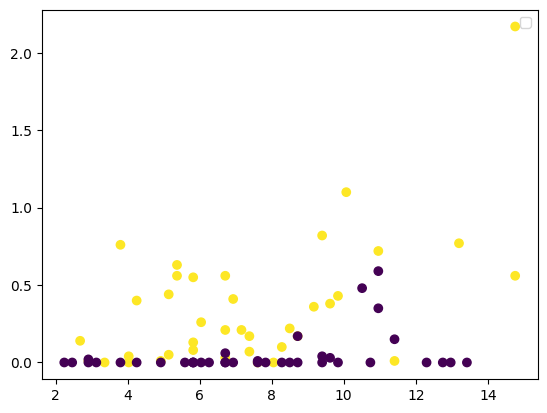

In [83]:
plt.scatter(sample_t["AWND"], sample_t["PRCP"], c=sample_t["WT03"])
plt.legend()

Repeat the process using min and max temperature as the predictors for thunder.

In [57]:
labels = sample_t["WT03"]
features = sample_t.iloc[:,7:9]
features
train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features,labels, test_size=.25)

In [58]:
logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.578783
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   WT03   No. Observations:                   57
Model:                          Logit   Df Residuals:                       54
Method:                           MLE   Df Model:                            2
Date:                Fri, 14 Nov 2025   Pseudo R-squ.:                  0.1633
Time:                        14:39:52   Log-Likelihood:                -32.991
converged:                       True   LL-Null:                       -39.430
Covariance Type:            nonrobust   LLR p-value:                  0.001597
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.9973      1.478     -2.705      0.007      -6.894      -1.101
TMAX           0.0140      0.

In [60]:
predicted = result.predict()
y_pred = []
for y in predicted:
    if y > .5:
        y = 1
        y_pred.append(y)
    elif y < .5:
        y = 0
        y_pred.append(y)

len(y_pred)

57

In [61]:
metrics.accuracy_score(train_labels, y_pred)

0.7192982456140351

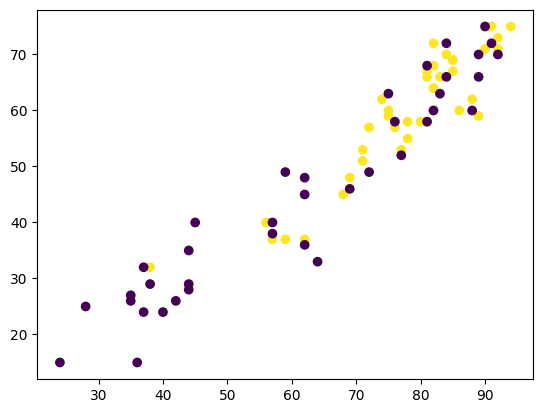

In [84]:
plt.scatter(sample_t["TMAX"], sample_t["TMIN"], c=sample_t["WT03"])
